
# Multi-Label Classification with MNIST Digits


In this notebook, you will learn how to:
1. Train a CNN to detect all digit classes present in each image.
2. Evaluate a multi-label classifier using precision, recall, binary accuracy, and exact-match accuracy.

---

## Problem description

Normal MNIST is a **single-label classification** problem:

> One image contains one digit, and the model predicts one class.

In this notebook, each image contains **multiple digits**, so the task becomes a **multi-label classification** problem:

> One image may contain several digit classes, and the model must predict all digit classes that appear.

For example, if an image contains digits `1`, `4`, and `9`, the target label is:

```text
[0, 1, 0, 0, 1, 0, 0, 0, 0, 1]
```

Each position represents one digit from `0` to `9`.


# 1. Imports and global settings

In [1]:
import os
import random
import numpy as np
import torch
from torchvision import datasets, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2026-06-28 17:46:10.280652: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-28 17:46:10.281078: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-28 17:46:10.347152: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-28 17:46:12.332260: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
# Reproducibility seed
# Using a fixed seed helps make results more repeatable
SEED = 42

def fix_random_seed(seed=SEED):
    """Fix random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    tf.random.set_seed(seed)

fix_random_seed(SEED)
print("Setup complete")


Setup complete



# 2. Data preparation

The images are saved as `uint8` values from `0` to `255`.

For Keras training, we convert them to:

```text
float32 values in [0, 1]
```

and reshape them to:

```text
[N, 56, 56, 1]
```

The labels are loaded as:

```text
[N, 10]
```


In [3]:
def load_data_pt(path):
    """
    Load one saved .pt split and convert it to Keras-friendly arrays.

    Returns
    -------
    images:
        NumPy array of shape [N, 56, 56, 1], values in [0, 1].

    labels:
        NumPy array of shape [N, 10].
        These are multi-hot labels used for training.
    """
    data = torch.load(path, map_location="cpu")

    # Convert [N, 56, 56] uint8 to [N, 56, 56, 1] float32.
    images = data["images"].numpy().astype("float32") / 255.0
    images = np.expand_dims(images, axis=-1)

    # Multi-label targets.
    labels = data["labels"].numpy().astype("float32")

    # Extra metadata, not required for model training.
    center_labels = data["center_labels"].numpy().astype("int64")
    count_labels = data["count_labels"].numpy().astype("int64")

    meta = {
        "center_labels": center_labels,
        "count_labels": count_labels,
        "num_digits": data["num_digits"].numpy().astype("int64"),
        "all_digit_labels": data["all_digit_labels"].numpy().astype("int64"),
        "all_positions": data["all_positions"].numpy().astype("int64"),
        "label_type": data.get("label_type", None),
    }

    return images, labels, meta

In [4]:

# File paths for train, validation, and test.
train_path = os.path.join("./data/train.pt")
val_path = os.path.join("./data/val.pt")
test_path = os.path.join("./data/test.pt")

# Load files if they exist.
if all(os.path.exists(p) for p in [train_path, val_path, test_path]):
    x_train, y_train, meta_train = load_data_pt(train_path)
    x_val, y_val, meta_val = load_data_pt(val_path)
    x_test, y_test, meta_test = load_data_pt(test_path)
    
    print("Data loaded successfully.")
    print("Train:", x_train.shape, y_train.shape)
    print("Val:  ", x_val.shape, y_val.shape)
    print("Test: ", x_test.shape, y_test.shape)
    print("You can now proceed to model training and evaluation.")
else:
    print("Dataset files not found yet.")


Data loaded successfully.
Train: (50000, 64, 64, 1) (50000, 10)
Val:   (10000, 64, 64, 1) (10000, 10)
Test:  (10000, 64, 64, 1) (10000, 10)
You can now proceed to model training and evaluation.



# 3. Visualization

Before training, always visualize some samples.


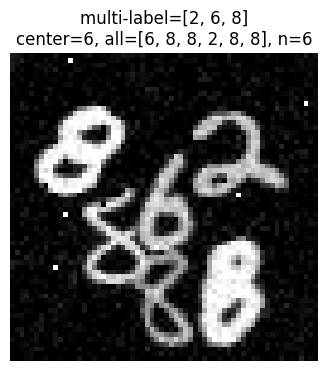

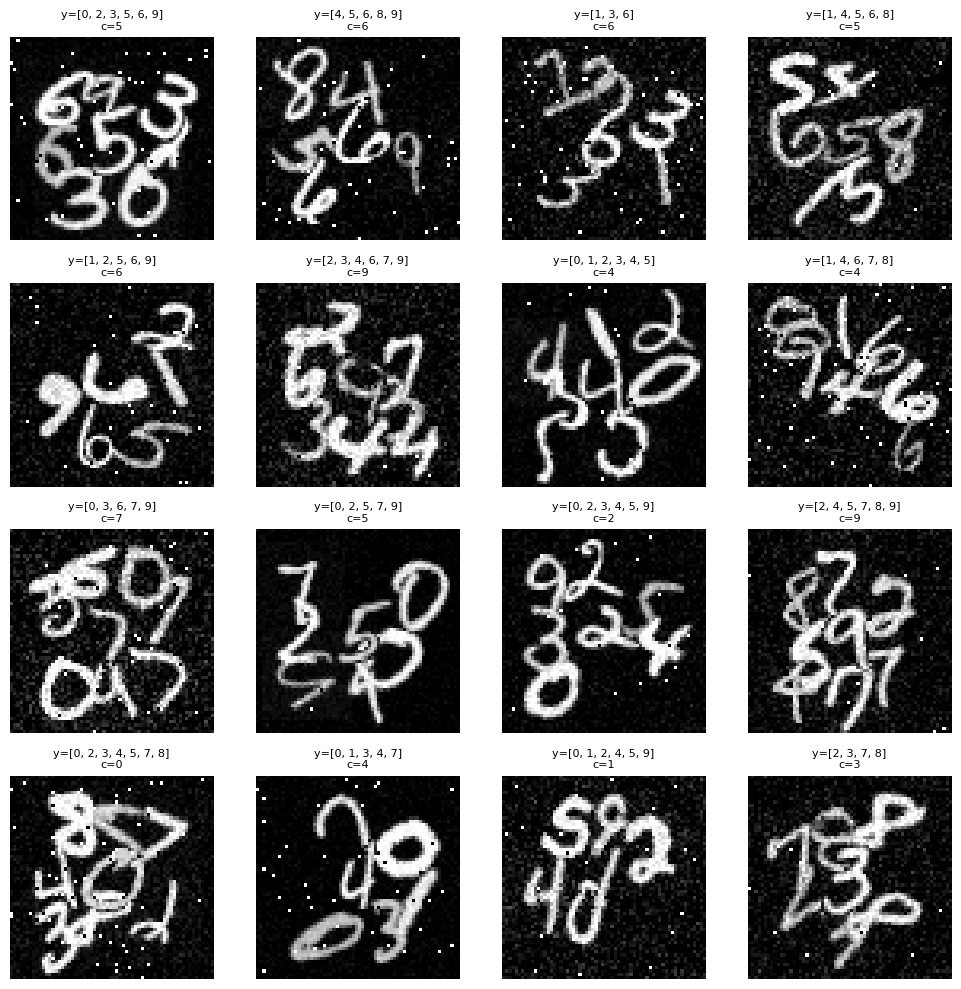

In [5]:
def multihot_to_digits(multihot):
    """
    Convert a multi-hot vector into a list of digit labels.

    Example:
        [0, 1, 0, 0, 1, 0, 0, 0, 0, 1]
        becomes
        [1, 4, 9]
    """
    return np.where(multihot >= 0.5)[0].tolist()


def visualize_one_sample(images, labels, meta, idx=0):
    """Visualize one generated image and its labels."""
    img = images[idx].squeeze()

    digits_present = multihot_to_digits(labels[idx])
    center_label = meta["center_labels"][idx]
    all_labels = meta["all_digit_labels"][idx]
    n_digits = meta["num_digits"][idx]

    # Remove padding values.
    valid_all_labels = all_labels[all_labels >= 0].tolist()

    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap="gray")
    plt.title(
        f"multi-label={digits_present}\n"
        f"center={center_label}, all={valid_all_labels}, n={n_digits}"
    )
    plt.axis("off")
    plt.show()


def visualize_grid(images, labels, meta, num_samples=16):
    """Visualize a grid of random samples."""
    rows = int(np.sqrt(num_samples))
    cols = int(np.ceil(num_samples / rows))

    plt.figure(figsize=(10, 10))

    for i in range(num_samples):
        idx = random.randint(0, len(images) - 1)

        img = images[idx].squeeze()
        digits_present = multihot_to_digits(labels[idx])
        center_label = meta["center_labels"][idx]

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"y={digits_present}\nc={center_label}", fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Visualize samples if the dataset has been loaded.
if "x_train" in globals():
    visualize_one_sample(x_train, y_train, meta_train, idx=0)
    visualize_grid(x_train, y_train, meta_train, num_samples=16)



# 3. Evaluation metrics for multi-label classification

Multi-label classification needs different metrics from normal MNIST.

## Binary accuracy

Checks each of the 10 outputs independently.

This can be misleading because most labels are `0`.

## Precision

Among predicted digits, how many are correct?

High precision means the model does not predict many extra wrong digits.

## Recall

Among true digits, how many did the model find?

High recall means the model finds most of the digits that are present.

## Exact-match accuracy

The strictest metric.

A prediction is correct only if the entire 10-dimensional vector is correct.

Example:

```text
true = [1, 4, 9]
pred = [1, 4, 9]
correct
```

```text
true = [1, 4, 9]
pred = [1, 4]
wrong
```

```text
true = [1, 4, 9]
pred = [1, 4, 7, 9]
wrong
```


In [6]:
def exact_match_accuracy(y_true, y_pred):
    """
    Exact-match accuracy for multi-label classification.

    Steps:
    1. Convert predicted probabilities to binary labels using a threshold.
    2. Compare the whole predicted vector with the true vector.
    3. Count the sample as correct only if every label matches.

    This metric is strict but useful.
    """
    y_pred_binary = tf.cast(y_pred >= 0.5, tf.float32)

    # For each sample, check whether all 10 labels are correct.
    matches = tf.reduce_all(tf.equal(y_true, y_pred_binary), axis=1)

    return tf.reduce_mean(tf.cast(matches, tf.float32))



# 4. Build the CNN model

The model architecture is a simple CNN:

1. Convolution + pooling
2. Convolution + pooling
3. Convolution + pooling
4. Dense layer
5. Output layer

The output layer has 10 neurons.

Each neuron answers one question:

> Is this digit present in the image?

Because each answer is independent, we use:

```python
activation="sigmoid"
```

and:

```python
loss="binary_crossentropy"
```


In [7]:
def build_cnn_model(input_shape=(24, 24, 1)):
    """
    Build a CNN for multi-label classification.

    Important:
    ----------
    The final activation is sigmoid, not softmax.

    Sigmoid allows multiple output classes to be active at the same time.
    """
    inputs = keras.Input(shape=input_shape)
    x = inputs

    # First convolution block.
    x = layers.Conv2D(32, kernel_size=3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    # Second convolution block.
    x = layers.Conv2D(64, kernel_size=3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    # Third convolution block.
    x = layers.Conv2D(128, kernel_size=3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)

    # Classifier head.
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    # Multi-label output.
    # Each output neuron predicts whether one digit class is present.
    outputs = layers.Dense(10, activation="sigmoid")(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs, 
        name="multi_label_cnn"
    )

    return model

In [8]:
# Build the model
INPUT_SHAPE = (64, 64, 1)
model = build_cnn_model(input_shape=INPUT_SHAPE)

E0000 00:00:1782668775.984563 2606539 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
E0000 00:00:1782668776.002085 2606539 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1782668776.016569 2606539 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [9]:
# Compile the model with appropriate loss and metrics for multi-label classification.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="binary_accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        exact_match_accuracy,
    ],
)

In [10]:
# Display the model architecture.
model.summary()

Model: "multi_label_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,192,650 (8.36 MB)

 Trainable params: 2,192,650 (8.36 MB)

 Non-trainable params: 0 (0.00 B)


# 5. Train the model

During training, observe:

- training loss
- validation loss
- binary accuracy
- precision
- recall
- exact-match accuracy

If training accuracy is high but validation metrics are low, the model may be overfitting.


In [11]:
# Training hyperparameters.
BATCH_SIZE = 128
EPOCHS = 100
# Use callbacks to improve training.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-5,
    ),
]

In [12]:
# Train the model.
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/100
  2/391 ━━━━━━━━━━━━━━━━━━━━ 48s 124ms/step - binary_accuracy: 0.5002 - exact_match_accuracy: 0.0059 - loss: 0.6953 - precision: 0.5210 - recall: 0.4441

391/391 ━━━━━━━━━━━━━━━━━━━━ 47s 116ms/step - binary_accuracy: 0.6207 - exact_match_accuracy: 0.0089 - loss: 0.6335 - precision: 0.6201 - recall: 0.6961 - val_binary_accuracy: 0.7014 - val_exact_match_accuracy: 0.0284 - val_loss: 0.5625 - val_precision: 0.7144 - val_recall: 0.7073 - learning_rate: 0.0010
Epoch 2/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 110ms/step - binary_accuracy: 0.7253 - exact_match_accuracy: 0.0390 - loss: 0.5307 - precision: 0.7410 - recall: 0.7243 - val_binary_accuracy: 0.7597 - val_exact_match_accuracy: 0.0666 - val_loss: 0.4841 - val_precision: 0.7798 - val_recall: 0.7482 - learning_rate: 0.0010
Epoch 3/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 108ms/step - binary_accuracy: 0.7669 - exact_match_accuracy: 0.0704 - loss: 0.4736 - precision: 0.7863 - recall: 0.7570 - val_binary_accuracy: 0.7853 - val_exact_match_accuracy: 0.0943 - val_loss: 0.4475 - val_precision: 0.8147 - val_recall: 0.7588 - learning_rate: 0.0010
Epoch 4/100
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 107ms/step - 

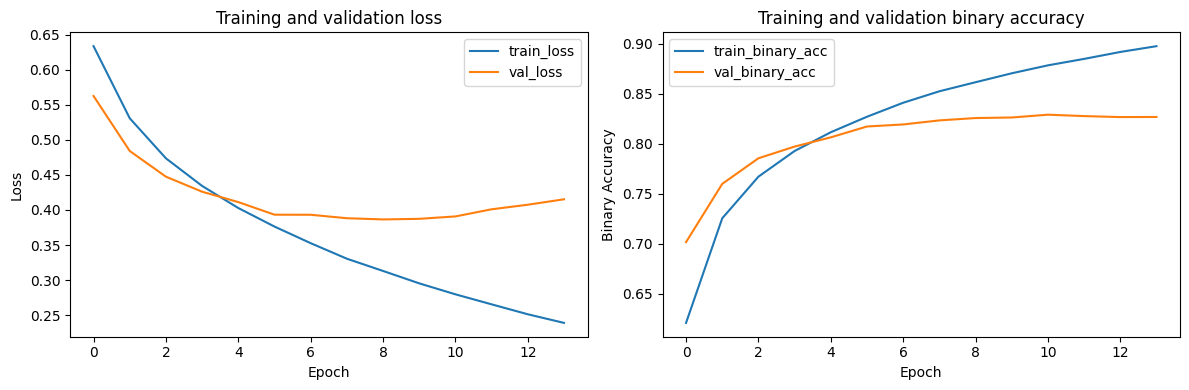

In [13]:
# Plot training history if available.

if "history" in globals():
    plt.figure(figsize=(12, 4))

    # Loss curve.
    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and validation loss")
    plt.legend()

    # Binary accuracy curve.
    plt.subplot(1, 2, 2)
    plt.plot(history.history["binary_accuracy"], label="train_binary_acc")
    plt.plot(history.history["val_binary_accuracy"], label="val_binary_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Binary Accuracy")
    plt.title("Training and validation binary accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No training history found.")



# 6. Evaluate the model

The test set is used only after training.

Important:

- `binary_accuracy` measures label-wise correctness.
- `precision` measures whether predicted labels are correct.
- `recall` measures whether true labels are found.
- `exact_match_accuracy` checks whether the whole label set is correct for each image.

For this task, precision, recall, and exact-match accuracy are usually more informative than binary accuracy.


In [14]:
# Evaluate the model on the test set.
results = model.evaluate(x_test, y_test, verbose=1)

# print("\nTest results:")
# for name, value in zip(model.metrics_names, results):
#     print(f"{name}: {value:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - binary_accuracy: 0.8319 - exact_match_accuracy: 0.1714 - loss: 0.3720 - precision: 0.8562 - recall: 0.8136



# 7. Visualize predictions

The model outputs probabilities.

Example:

```text
digit 0: 0.02
digit 1: 0.91
digit 2: 0.04
...
```

If a probability is greater than or equal to the threshold, that digit is predicted as present.


In [15]:
# Prediction helper functions
# Student donnt allow to change the threshold value
PREDICTION_THRESHOLD=0.5
def probs_to_digits(probs, threshold=PREDICTION_THRESHOLD):
    """Convert prediction probabilities into a list of predicted digits."""
    return np.where(probs >= threshold)[0].tolist()


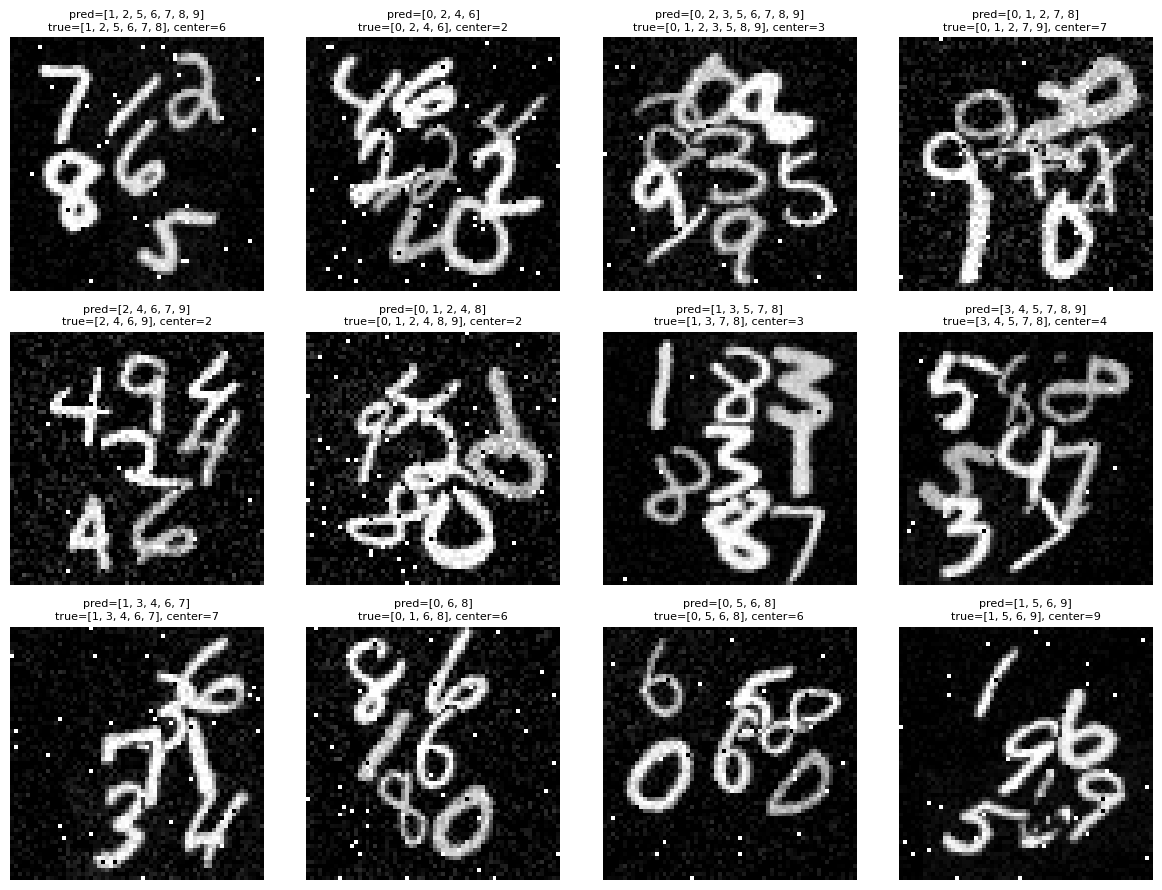

In [16]:

# Visualize several test predictions.

if "model" in globals() and "x_test" in globals():
    indices = np.random.choice(len(x_test), size=12, replace=False)
    probs = model.predict(x_test[indices], verbose=0)

    plt.figure(figsize=(12, 9))

    for i, idx in enumerate(indices):
        true_digits = multihot_to_digits(y_test[idx])
        pred_digits = probs_to_digits(probs[i], threshold=PREDICTION_THRESHOLD)
        center_label = meta_test["center_labels"][idx]

        plt.subplot(3, 4, i + 1)
        plt.imshow(x_test[idx].squeeze(), cmap="gray")
        plt.title(
            f"pred={pred_digits}\n"
            f"true={true_digits}, center={center_label}",
            fontsize=8,
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Model or test data not available.")


In [17]:

# Inspect one test prediction in detail.
idx = 0
prob = model.predict(x_test[idx:idx + 1], verbose=0)[0]

print("True digits:", multihot_to_digits(y_test[idx]))
print("Predicted digits:", probs_to_digits(prob))
print("Center label:", meta_test["center_labels"][idx])
print()

print("Prediction probabilities:")
for digit, p in enumerate(prob):
    print(f"digit {digit}: {p:.4f}")


True digits: [2, 3, 5, 7, 9]
Predicted digits: [2, 3, 5, 7]
Center label: 7

Prediction probabilities:
digit 0: 0.1620
digit 1: 0.0431
digit 2: 0.9884
digit 3: 0.9454
digit 4: 0.2160
digit 5: 0.6101
digit 6: 0.1952
digit 7: 0.9923
digit 8: 0.1489
digit 9: 0.1156


# Lab Exercise: Improve and Evaluate a CNN Model

## Objective

In this lab exercise, you will improve an existing Convolutional Neural Network (CNN) model and compare its performance before and after your changes.

Your goal is to identify one or more ways to improve the model, retrain it, and evaluate whether the changes lead to better results.

## Tasks

### 1. Review the Baseline CNN Model

Start by examining the given CNN model. Pay attention to:

* The shared CNN layers
* The five output heads
* The training configuration
* The current evaluation results

Record the baseline metrics before making any changes.

### 2. Improve the CNN Model

Modify the CNN model or training process to improve performance. You may try one or more of the following:

* Add or remove convolutional layers
* Change the number of filters
* Add dropout or batch normalization
* Adjust the learning rate
* Change the batch size
* Train for more epochs
* Apply or modify data augmentation
* Use a different optimizer

Clearly explain what changes you made and why.

### 3. Train and Evaluate the Improved Model

Train the improved model using the same dataset.

After training, evaluate the new model and compare it with the baseline model using:

* Per-position accuracy
* Exact-match accuracy

## Report Requirements

Write a short report using the structure below.

### 1. Dataset Description

Describe the dataset used in this experiment. Include:

* Image size
* Label format
* Train/validation/test split

### 2. Model Architecture

Describe the model architecture. Include:

* Shared CNN layers
* Five output heads
* Any changes made to the baseline architecture

### 3. Training Setup

Describe the training configuration. Include:

* Number of epochs
* Batch size
* Learning rate
* Optimizer
* Data augmentation settings

### 4. Results

Present and compare the results before and after your improvements.

Include:

* Per-position accuracy
* Exact-match accuracy
* A clear comparison table or summary

### 5. Error Analysis

Analyze common mistakes made by the model.

Include examples such as:

* Incorrect predictions for specific positions
* Confusing similar-looking characters or labels
* Cases where the full output sequence was almost correct but not an exact match

### 6. Conclusion

Summarize your findings.

Discuss:

* What changes improved the model
* What changes did not help
* Possible future improvements

## Submission

Submit your short report together with your updated code or notebook.

Your report should clearly show the comparison between the baseline CNN and your improved CNN.
